In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sb

In [2]:
# importing the dataset

In [3]:
a=pd.read_csv("netflix_titles.csv") #using file name instead of path
a

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...
...,...,...,...,...,...,...,...,...,...,...,...,...
8802,s8803,Movie,Zodiac,David Fincher,"Mark Ruffalo, Jake Gyllenhaal, Robert Downey J...",United States,"November 20, 2019",2007,R,158 min,"Cult Movies, Dramas, Thrillers","A political cartoonist, a crime reporter and a..."
8803,s8804,TV Show,Zombie Dumb,NaN,NaN,NaN,"July 1, 2019",2018,TV-Y7,2 Seasons,"Kids' TV, Korean TV Shows, TV Comedies","While living alone in a spooky town, a young g..."
8804,s8805,Movie,Zombieland,Ruben Fleischer,"Jesse Eisenberg, Woody Harrelson, Emma Stone, ...",United States,"November 1, 2019",2009,R,88 min,"Comedies, Horror Movies",Looking to survive in a world taken over by zo...
8805,s8806,Movie,Zoom,Peter Hewitt,"Tim Allen, Courteney Cox, Chevy Chase, Kate Ma...",United States,"January 11, 2020",2006,PG,88 min,"Children & Family Movies, Comedies","Dragged from civilian life, a former superhero..."


In [4]:
#checking for any null values
a.isnull().any()

show_id         False
type            False
title           False
director         True
cast             True
country          True
date_added       True
release_year    False
rating           True
duration         True
listed_in       False
description     False
dtype: bool

In [5]:
a.isnull().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

[Text(3, 0, '0'),
 Text(3, 0, '0'),
 Text(3, 0, '0'),
 Text(3, 0, '29.908'),
 Text(3, 0, '9.36755'),
 Text(3, 0, '9.43568'),
 Text(3, 0, '0.113546'),
 Text(3, 0, '0'),
 Text(3, 0, '0.0454184'),
 Text(3, 0, '0.0340638'),
 Text(3, 0, '0'),
 Text(3, 0, '0')]

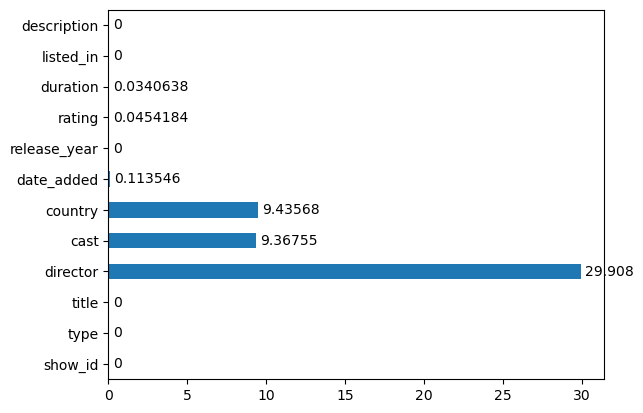

In [6]:
null_values =a.isnull().sum()
Missing_Percentage= (a.isnull().sum() / len(a)) * 100
b=Missing_Percentage.plot(kind="barh")
plt.bar_label(b.containers[0],padding=3)


In [7]:
#2

date_added
2008.0       2
2009.0       2
2010.0       1
2011.0      13
2012.0       3
2013.0      11
2014.0      24
2015.0      82
2016.0     429
2017.0    1188
2018.0    1649
2019.0    2016
2020.0    1879
2021.0    1498
Name: count, dtype: int64


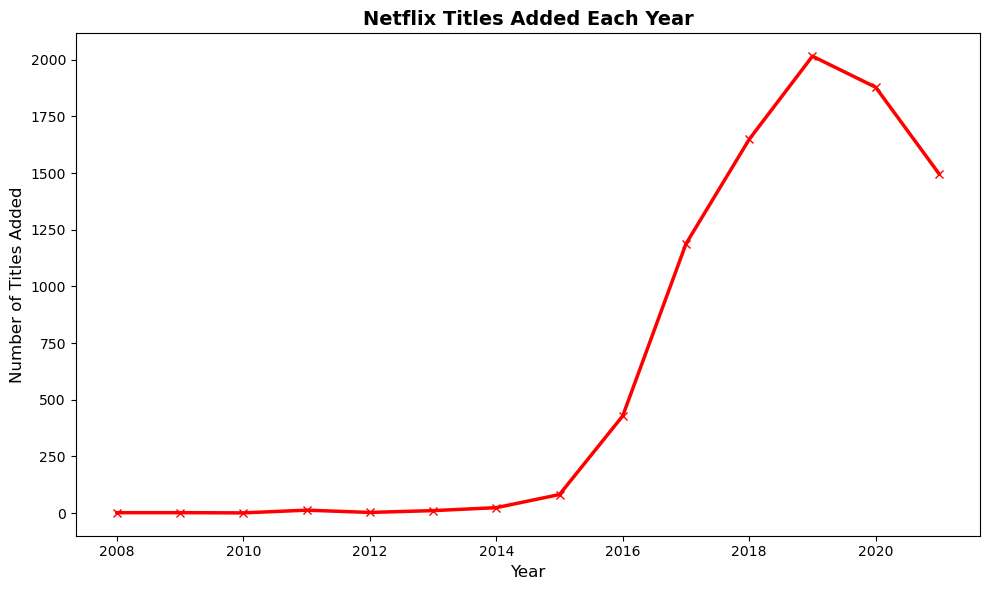

In [65]:
# 1. Convert the 'date_added' column to datetime format
# .str.strip() is used just in case there are leading/trailing white spaces in the strings
a['date_added'] = pd.to_datetime(a['date_added'])

# 2. Extract the year from the datetime column and count titles per year
yearly_counts = a['date_added'].dt.year.value_counts().sort_index()

# Display the counts in your console
print(yearly_counts)

# 3. Plot a line chart to show the growth trend
plt.figure(figsize=(10, 6))
yearly_counts.plot(kind='line', marker='x', color='red', linewidth=2.5)

# Customize the chart
plt.title('Netflix Titles Added Each Year', fontsize=14, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Number of Titles Added', fontsize=12)

# Show the plot
plt.tight_layout()
plt.show()

In [ ]:
#3

In [ ]:
a

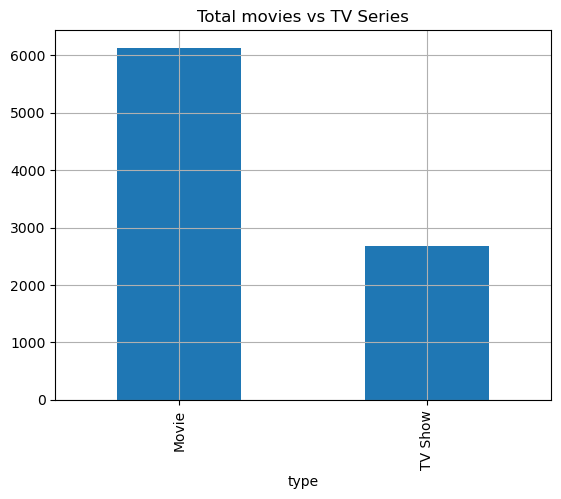

In [63]:
a["type"].value_counts().plot(kind="bar")

plt.title("Total movies vs TV Series")
plt.grid()
plt.show()

In [ ]:
#4

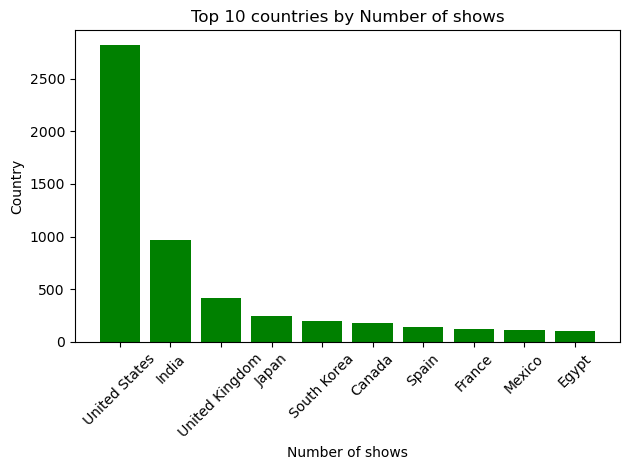

In [11]:
country_counts = a['country'].value_counts().head(10)
plt.bar(country_counts.index, country_counts.values,color='green')
plt.xticks(rotation=45)
plt.title('Top 10 countries by Number of shows')
plt.xlabel('Number of shows')
plt.ylabel('Country')
plt.tight_layout()
plt.show()

In [ ]:
#5

<Axes: ylabel='listed_in'>

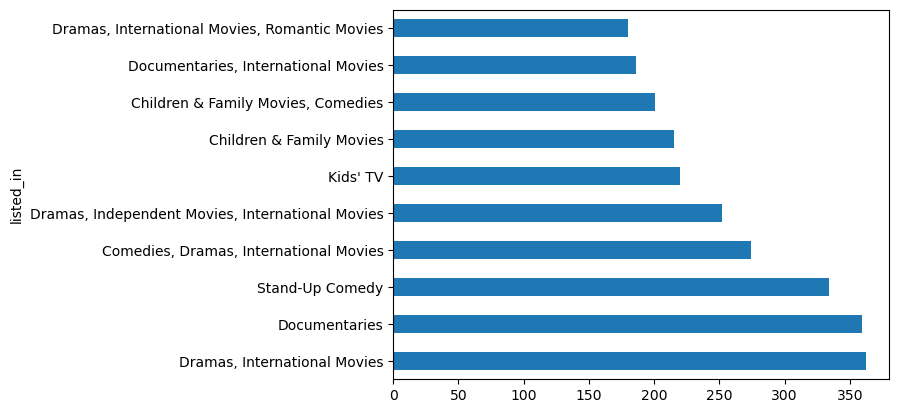

In [55]:

a["listed_in"].value_counts().head(10).plot(kind="barh")


<BarContainer object of 10 artists>

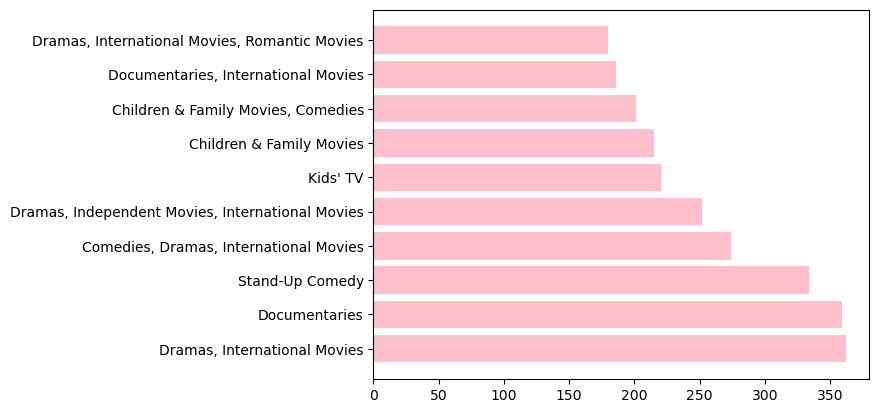

In [61]:
genre_counts = a["listed_in"].value_counts().head(10)
genre_counts
plt.barh(genre_counts.index, genre_counts.values,color='pink')

In [ ]:
#6

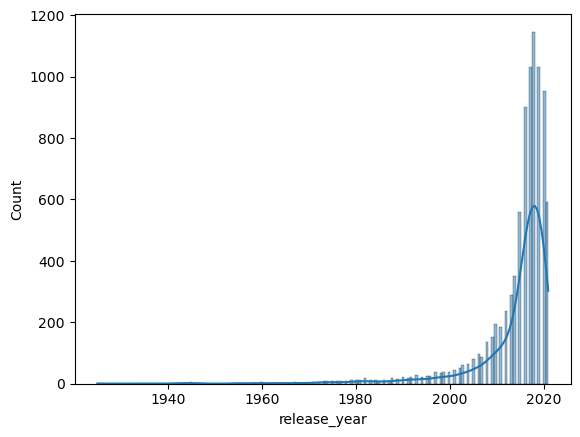

In [73]:
a.describe()
a
sb.histplot(a["release_year"],kde=True)
plt.show()

In [ ]:
#7

In [164]:
d=a[a["type"]=="Movie"]
d["duration"].sort_values(ascending=True)

3535     10 min
7849    100 min
8750    100 min
4698    100 min
2918    100 min
         ...   
8281     99 min
337      99 min
5541        NaN
5794        NaN
5813        NaN
Name: duration, Length: 6131, dtype: object

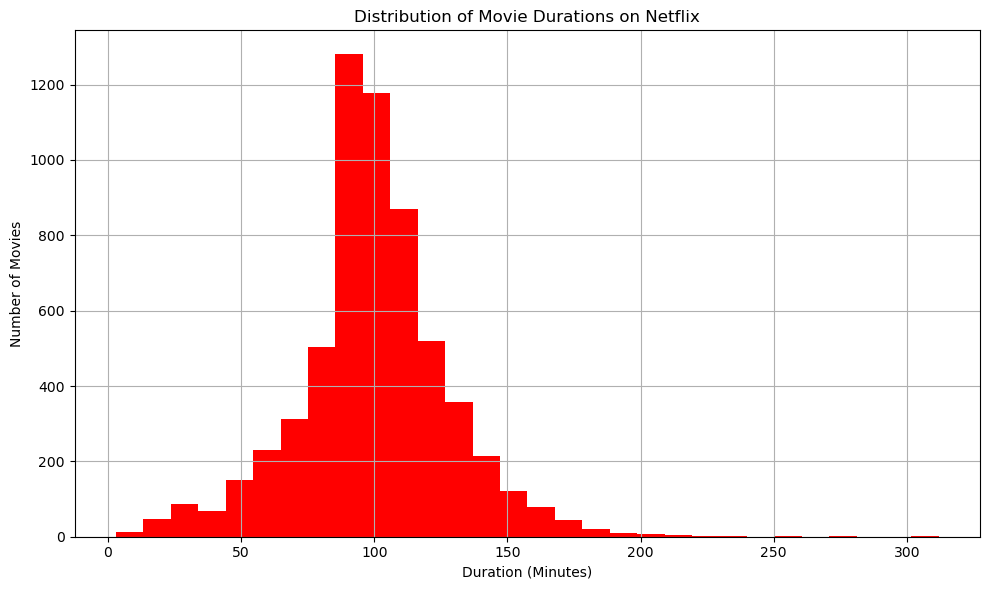

In [174]:
# 1. Filter the dataset to include only Movies using variable 'a'
movies_df = a[a['type'] == 'Movie'].copy()

# 2. Extract numerical values from the 'duration' column
movies_df['duration_num'] = (movies_df['duration'].str.replace(' min', '', regex=False).astype(float))

# 3. Calculate average, shortest, and longest movie duration
avg_duration = movies_df['duration_num'].mean()
shortest_duration = movies_df['duration_num'].min()
longest_duration = movies_df['duration_num'].max()


# 4. Visualize the distribution using a histogram
plt.figure(figsize=(10, 6))
plt.hist(movies_df['duration_num'].dropna(),bins=30,color='red')


plt.title('Distribution of Movie Durations on Netflix')
plt.xlabel('Duration (Minutes)')
plt.ylabel('Number of Movies')
plt.grid()

plt.tight_layout()
plt.show()

In [ ]:
#8

date_added
1.0     738
2.0     563
3.0     742
4.0     764
5.0     632
6.0     728
7.0     827
8.0     755
9.0     770
10.0    760
11.0    705
12.0    813
Name: count, dtype: int64


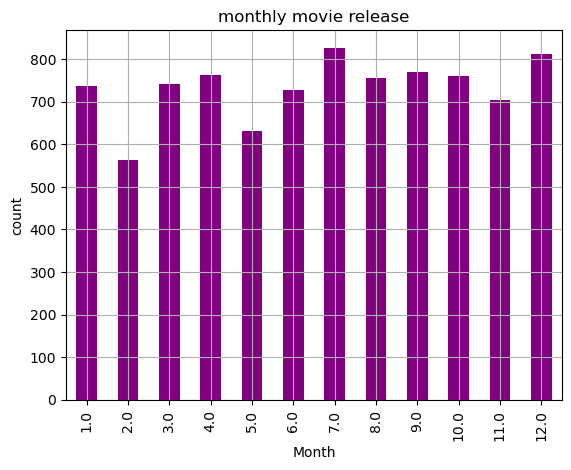

In [186]:
a
# 1. Convert the 'date_added' column to datetime format
# .str.strip() is used just in case there are leading/trailing white spaces in the strings
a['date_added'] = pd.to_datetime(a['date_added'])

# 2. Extract the year from the datetime column and count titles per year
monthly_counts = a['date_added'].dt.month.value_counts().sort_index()

# Display the counts in your console
print(monthly_counts)
monthly_counts.plot(kind='bar', color='purple', linewidth=2.5)
plt.xlabel("Month")
plt.ylabel("count")
plt.title("monthly movie release")
plt.grid()
plt.show()

In [ ]:
#9

<Axes: xlabel='director'>

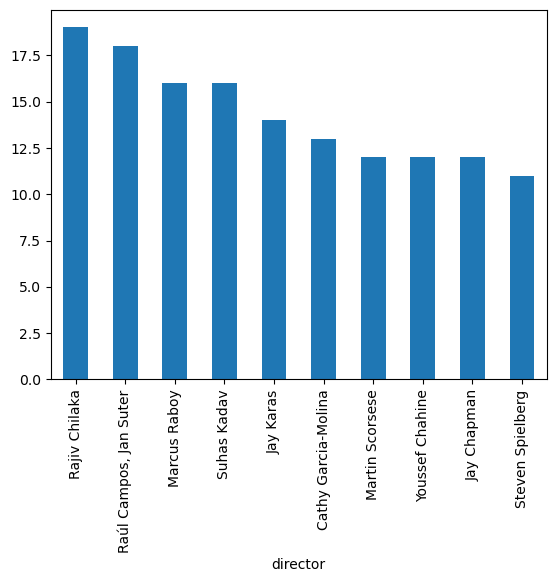

In [194]:
a["director"].value_counts().head(10).plot(kind="bar")

In [ ]:
#10